## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [337]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [338]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

df = pd.read_csv('penguins_data.csv')
df.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [339]:
df.shape

(344, 11)

In [340]:
df.dtypes

Species                    str
Island                     str
Clutch Completion          str
Date Egg                 int64
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                        str
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
dtype: object

In [341]:
df.isnull().sum()

Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64

In [342]:
df = df.dropna()
df.isnull().sum()

Species                0
Island                 0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64

### Изучение категориальных переменных

In [343]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
cat_cols

['Species', 'Island', 'Clutch Completion', 'Sex']

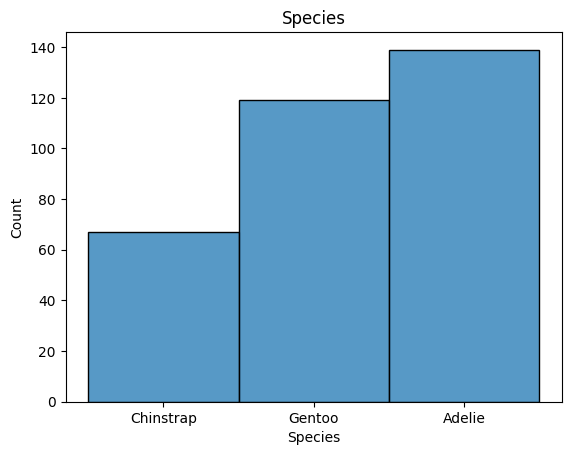

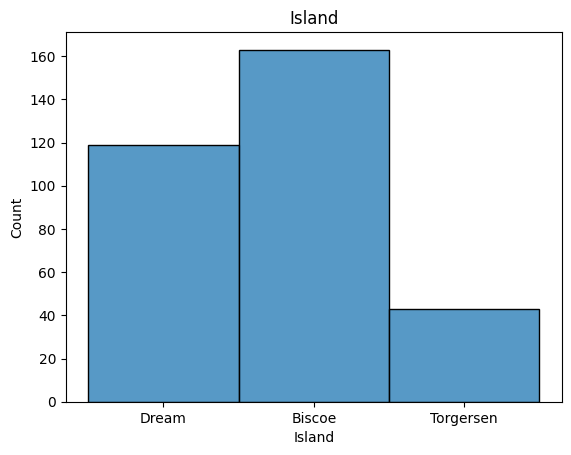

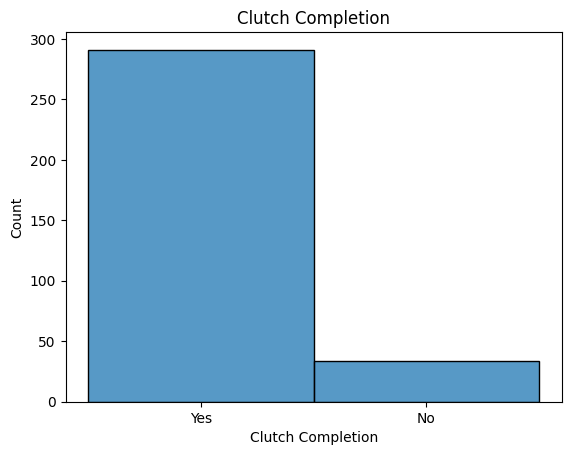

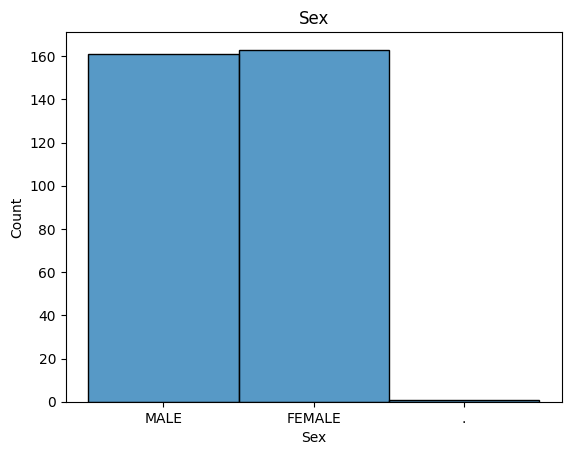

In [344]:
for col in cat_cols:
    sns.histplot(
        data = df,
        x = col
    )
    plt.title(col)
    plt.show()

Во первых, видим странный тип в переменной Sex
проверим что это

In [345]:
df.Sex.value_counts()

Sex
FEMALE    163
MALE      161
.           1
Name: count, dtype: int64

Давайте лучше выкинем точку чтоб не повышать размерность лишний раз

In [346]:
df = df[df.Sex != '.']
df.Sex.value_counts()

Sex
FEMALE    163
MALE      161
Name: count, dtype: int64

Самих категориальных признаков не так много (да и внутри не так много ка егорий), так что мы вполне можем использовать One-Hot кодирование. Я аппелирую к кол-ву признаков чтоб избежать проклятия размерности, с учетом того что данных довольно мало (всего лишь 324 записи)

In [347]:
categorical_cols = ['Island', 'Clutch Completion', 'Sex']

df = pd.get_dummies(
    df, 
    columns=categorical_cols,
    prefix=categorical_cols,
    prefix_sep='_',
    dtype=int
)

df.head()

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,Clutch Completion_No,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0,1,0,0,1,0,1
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,0,1,0,0,1,1,0
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1,0,0,0,1,1,0
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,0,1,0,0,1,1,0
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1,0,0,0,1,1,0


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [348]:
from sklearn.preprocessing import OrdinalEncoder

я не совсем понял, именно такой ли порядок нужен как в задании. ну на всякий случай я передал названия в том же порядке что и в задаче, чтоб получить на нужной нумерации

In [349]:
target_col = "Species"
species_order = [['Chinstrap', 'Gentoo', 'Adelie']]
enc = OrdinalEncoder(categories=species_order)
df[target_col] = enc.fit_transform(df[[target_col]])


X = df[[c for c in df.columns if c != target_col]]
y = df[target_col]

In [350]:
X.shape

(324, 14)

In [351]:
X.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,Clutch Completion_No,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0,1,0,0,1,0,1
1,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,0,1,0,0,1,1,0
2,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1,0,0,0,1,1,0
3,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,0,1,0,0,1,1,0
4,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1,0,0,0,1,1,0


In [352]:
y.head()

0    0.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Species, dtype: float64

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [353]:
from sklearn.model_selection import train_test_split
np.random.seed(42)

Давайте поговорим про stratify
Эта функция делает так, что в тестовой и контрольной выборках соблюдается балланс классов. Нам это нужно, чтоб не оказалось, что в одной выборке допустим не будет вообще какого-то редкого класса. Соответственно это базированная штука

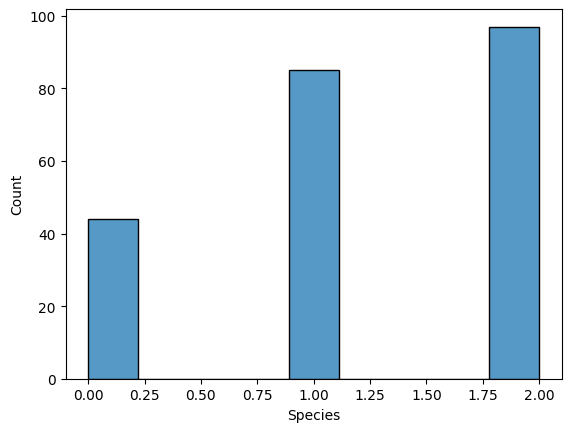

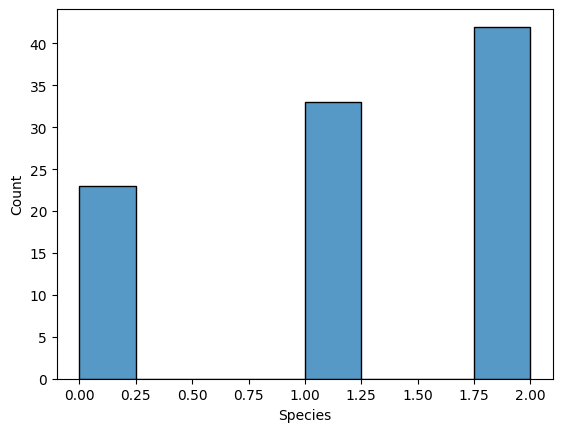

In [354]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.3,
    stratify=None,
)

sns.histplot(y_train)
plt.show()
sns.histplot(y_test)
plt.show()

как видим, балланс классов изменен

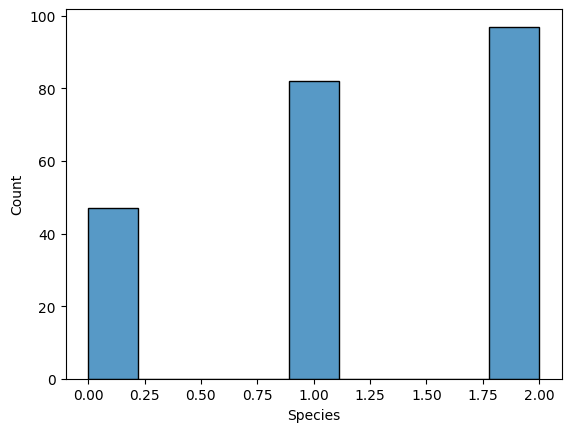

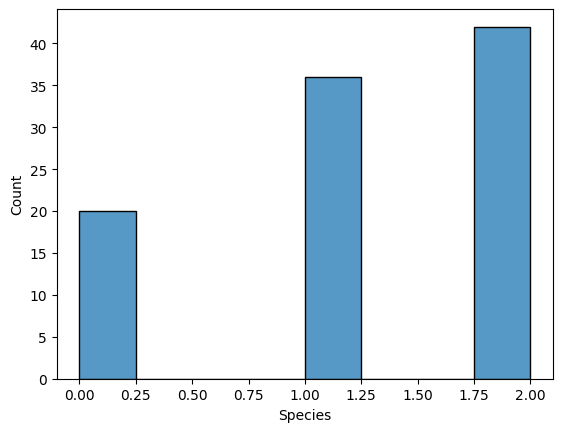

In [355]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.3,
    stratify=y,
)

sns.histplot(y_train)
plt.show()
sns.histplot(y_test)
plt.show()

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [356]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

In [357]:
X.columns

Index(['Date Egg', 'Culmen Length (mm)', 'Culmen Depth (mm)',
       'Flipper Length (mm)', 'Body Mass (g)', 'Delta 15 N (o/oo)',
       'Delta 13 C (o/oo)', 'Island_Biscoe', 'Island_Dream',
       'Island_Torgersen', 'Clutch Completion_No', 'Clutch Completion_Yes',
       'Sex_FEMALE', 'Sex_MALE'],
      dtype='str')

In [358]:
X_train_spec = X_train[["Flipper Length (mm)", "Body Mass (g)"]]
X_test_spec = X_test[["Flipper Length (mm)", "Body Mass (g)"]]
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train_spec)
X_test_scaled = scaler.transform(X_test_spec)

k_values = [1, 3, 5, 10, 15, 25]
models = []
train_scores = {}
test_scores = {}

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_scores[k] = train_acc
    test_scores[k] = test_acc
    print()
    print(f"k = {k}")
    print(f"Train accuracy: {train_acc}")
    print(f"Test accuracy: {test_acc}")

    models.append(model)


k = 1
Train accuracy: 0.9690265486725663
Test accuracy: 0.7551020408163265

k = 3
Train accuracy: 0.8495575221238938
Test accuracy: 0.7448979591836735

k = 5
Train accuracy: 0.831858407079646
Test accuracy: 0.7755102040816326

k = 10
Train accuracy: 0.827433628318584
Test accuracy: 0.7755102040816326

k = 15
Train accuracy: 0.8097345132743363
Test accuracy: 0.7653061224489796

k = 25
Train accuracy: 0.7964601769911505
Test accuracy: 0.8367346938775511


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [359]:
!pip install mlxtend


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [360]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

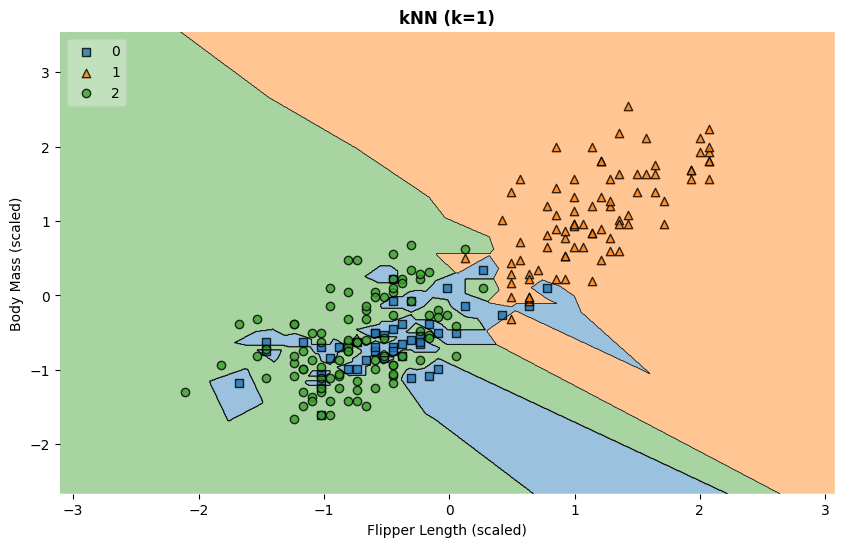

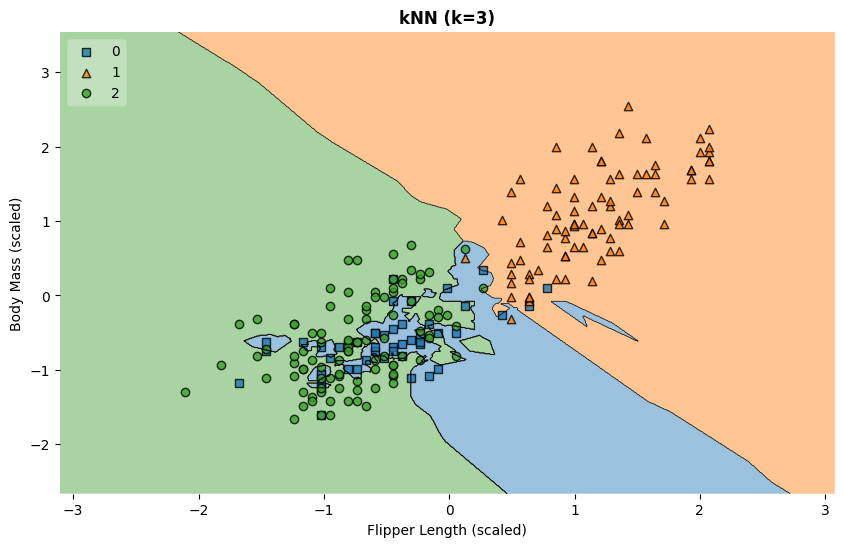

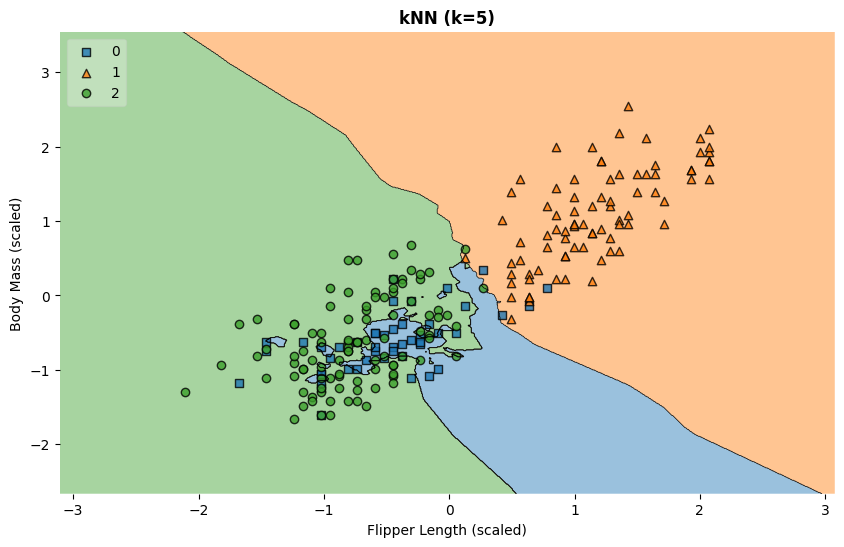

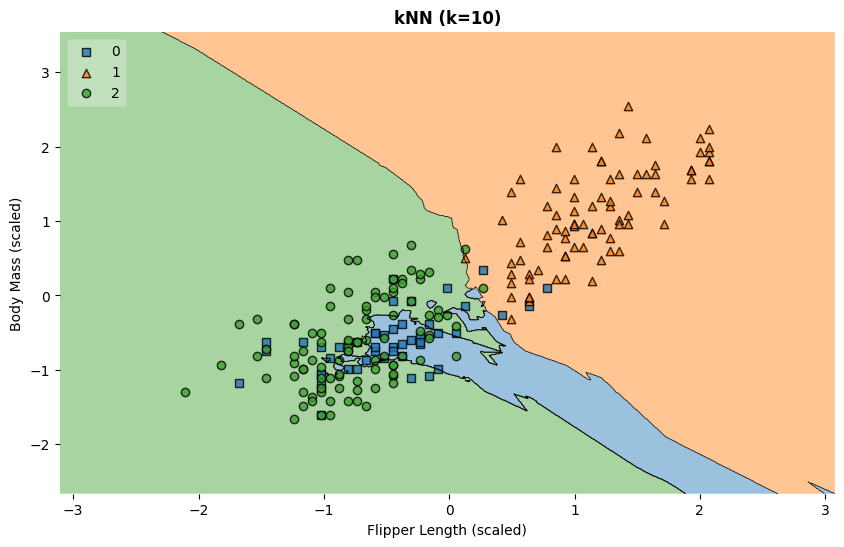

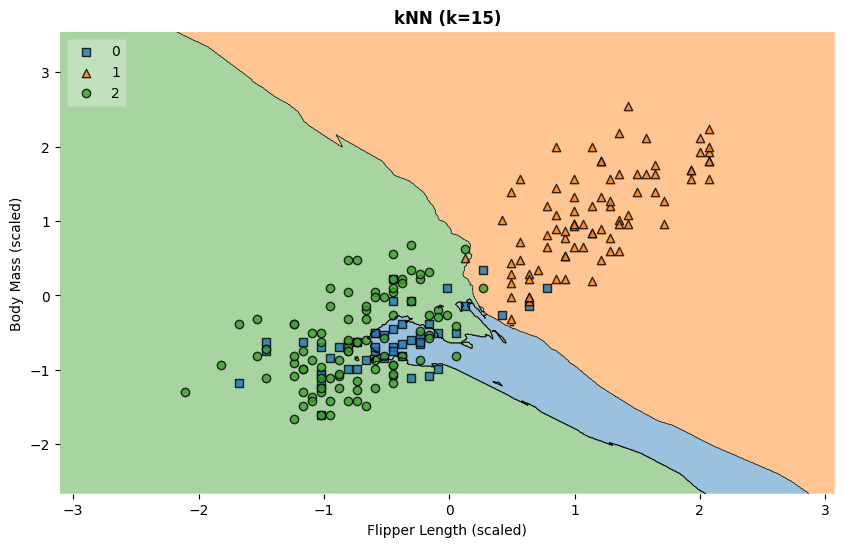

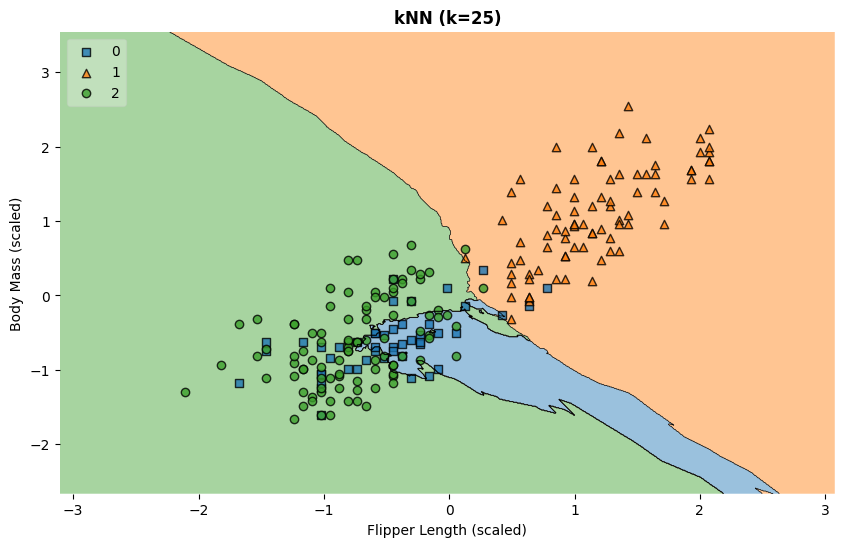

In [361]:
# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.
from mlxtend.plotting import plot_decision_regions

# Подготавливаем данные
X_plot = X_train_scaled

# Названия для графиков
model_names = [f'kNN (k={k})' for k in [1, 3, 5, 10, 15, 25]]

# Используем enumerate для обхода моделей
for idx, (model, title) in enumerate(zip(models, model_names)):
    plt.figure(figsize=(10, 6))
    plot_decision_regions(
        X=X_plot, 
        y=y_train.values.astype(np.int_), 
        clf=model, 
        legend=2
    )
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Flipper Length (scaled)', fontsize=10)
    plt.ylabel('Body Mass (scaled)', fontsize=10)
    plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Начнем с переобучения.
Очевидно, что на к = 1 модель переобучена. Это видно как по визуализации, где есть выделенные островки для единичных классов (модель жестко подстраивается под данные). Также, это видно по метрикам : на тесте они гораздо хуже чем на трэйне

Я считаю что оптимальным на данный момент является к = 25, так как он дал лушчий результат на тесте, но этот вывод требует обоснования. Нужно было бы применить кросс-валидацию и сделать грид-серч по параметру К с меньшим шагом

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

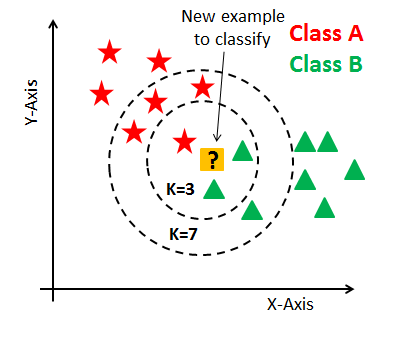

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [362]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k: int):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        if len(self.X_train) != len(self.y_train):
            raise TypeError("Количество объектов и меток не совпадает")
        if self.k > len(self.X_train):
            raise TypeError("k не может быть больше количества обучающих объектов")

    def count_distance(self, x, y):
        return np.linalg.norm(x - y, ord=2)

    def predict(self, X):
        if self.X_train is None or self.y_train is None:
            raise ValueError("Модель сначала надо обучить")
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        predictions = []
        for x in X:
            distances = []
            for x_train in self.X_train:
                dist = self.count_distance(x, x_train)
                distances.append(dist)
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train[k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)

In [363]:
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [364]:
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [365]:
k_values = [1, 3, 5, 9, 12, 15, 25, 33, 35]
test_scores = {}

for k in k_values:
    model = KNN(
        k=k,
    )
    model.fit(X_train_scaled, y_train)
    y_test_pred = model.predict(X_test_scaled)
    
    test_acc = accuracy_score(y_test, y_test_pred)
    test_scores[k] = test_acc

max_val = 0
max_k = -1

k_values = np.array(list(test_scores.keys()))
acc_values = np.array(list(test_scores.values()))
max_index = np.argmax(acc_values)
max_k = k_values[max_index]
max_val = acc_values[max_index]

print(f"При k={max_k} достигается accuracy = {max_val}")

При k=33 достигается accuracy = 0.8367346938775511


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

Я вытащил данные о признаках из доки

price price in US dollars (\$326--\$18,823)

carat weight of the diamond (0.2--5.01)

cut quality of the cut (Fair, Good, Very Good, Premium, Ideal)

color diamond colour, from J (worst) to D (best)

clarity a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))

x length in mm (0--10.74)

y width in mm (0--58.9)

z depth in mm (0--31.8)

depth total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)

table width of top of diamond relative to widest point (43--95)

In [366]:
df = pd.read_csv('diamonds.csv')
df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

In [367]:
print(df.isnull().sum())

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [368]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')

In [369]:
df = df[[col for col in df.columns if col != "Unnamed: 0"]]

Пропусков нет, все признаки мне кажутся полезными

**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

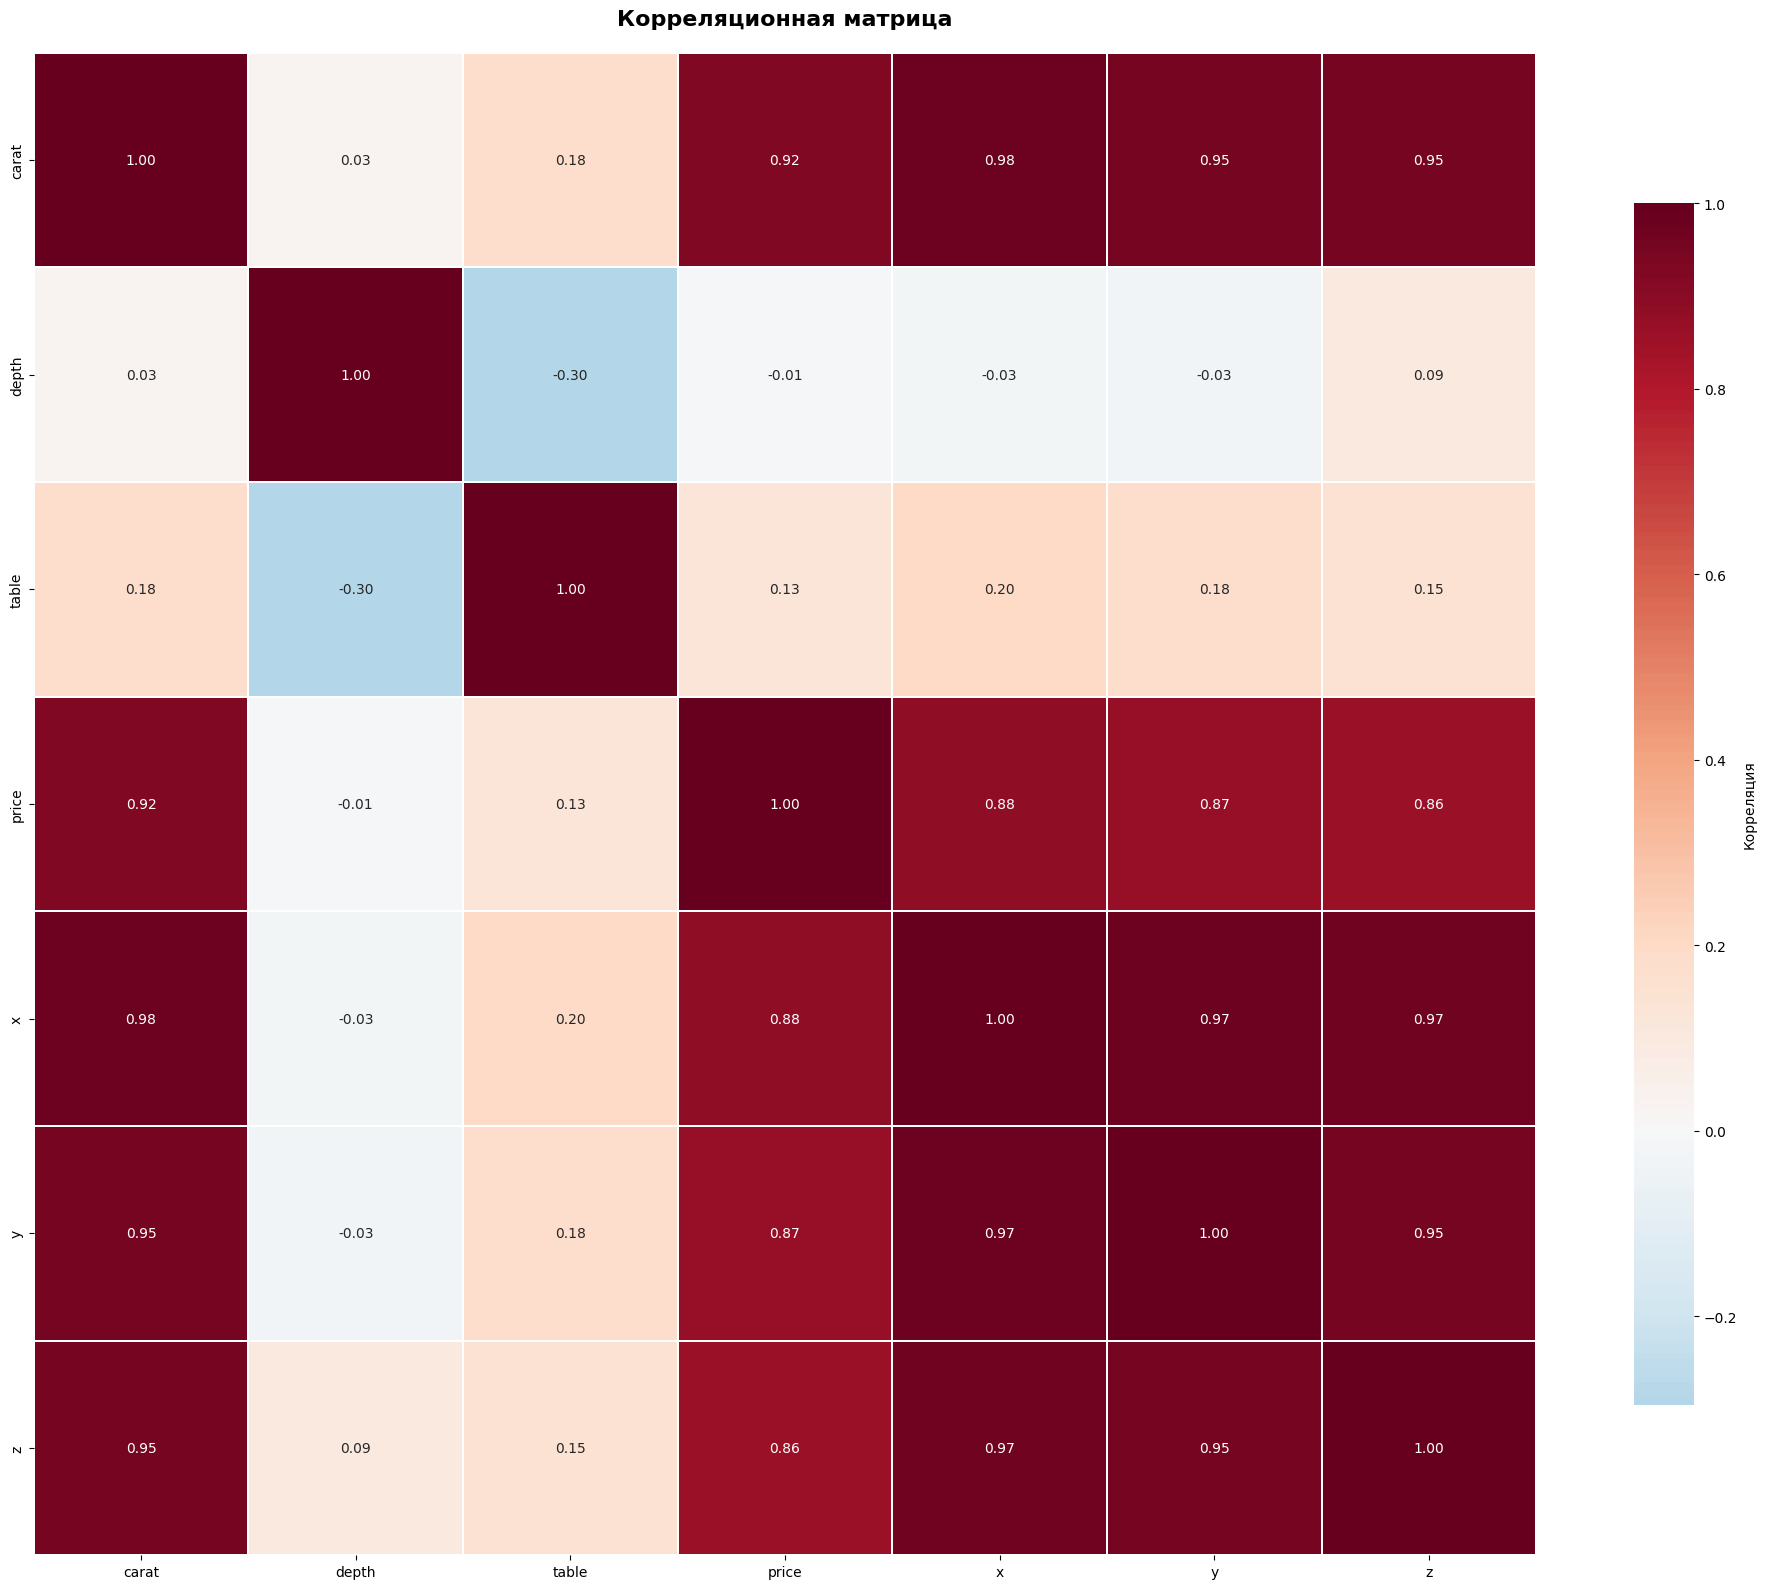

In [370]:
corr = df.select_dtypes(exclude=['object', 'string']).corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr, 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            linewidths=0.1,
            cbar_kws={"shrink": 0.8, "label": "Корреляция"},
            annot=True,
            fmt='.2f'
)
plt.title('Корреляционная матрица', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

количество карат имеет наибольшую корелляцию

затем идут x y z

проблема в том что они очень сильно кореллируют друг с другом, а также с кол-вом карат

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [371]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.to_list()

df = pd.get_dummies(
    df, 
    columns=categorical_cols,
    prefix=categorical_cols,
    prefix_sep='_',
    dtype=int
)

df.head()


,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,1,0,...,0,1,0,0,0,1,0,0,0,0


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

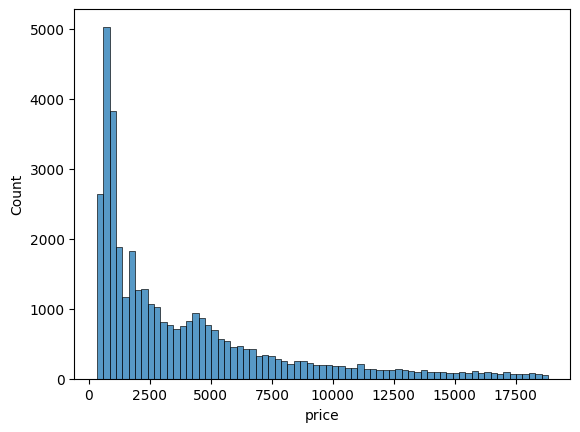

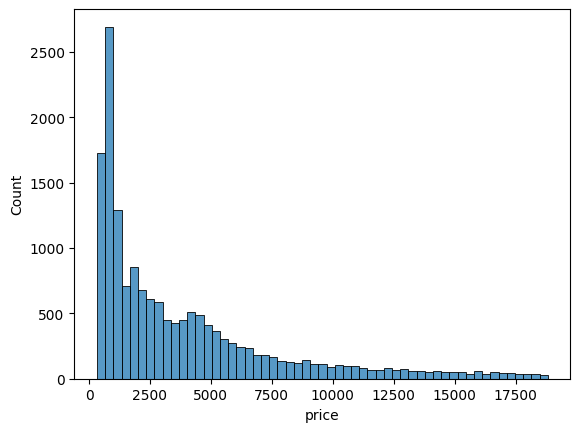

In [372]:
X_train, X_test, y_train, y_test = train_test_split(
    df[[col for col in df.columns if col != "price"]],
    df["price"],
    random_state=42,
    test_size=0.3
)

sns.histplot(y_train)
plt.show()
sns.histplot(y_test)
plt.show()

очень похоже на экспоненциальное распределение (на самом деле это неудивительно, так как оно оч хорошо моделлирует денежные метрики)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [373]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


когда признаки отмасштабированы, то в итоге мы получаем, что коэфициенты линейной регрессии своим размером могут показать насколько тот или иной признак важен в задаче. Также, это может помочь отловить переобучение, когда веса становятся очень большими

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [374]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [375]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)


mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"MSE_train: {mse_train}")
print(f"MSE_test: {mse_test}")

MSE_train: 1290541.914745061
MSE_test: 1244765.435715868


ну вот мне лично не оч понятно по метрикам насколько мы норм сделали

In [376]:
print(f"MSE_train: {np.sqrt(mse_train)}")
print(f"MSE_test: {np.sqrt(mse_test)}")

MSE_train: 1136.0202087749412
MSE_test: 1115.6905645006898


вот теперь понятнее

**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [377]:
X_train.columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Fair', 'cut_Good',
       'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_D', 'color_E',
       'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_I1',
       'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1',
       'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2'],
      dtype='str')

In [378]:

model.coef_

array([ 5.33861567e+03, -9.01738170e+01, -6.03322799e+01, -1.10041885e+03,
       -6.45891672e+00, -3.42589446e+01, -1.25711003e+02, -4.13959892e+01,
        5.19922058e+01,  1.64647406e+01,  1.37080731e+00,  2.11310541e+02,
        1.62482671e+02,  1.39770235e+02,  5.61664668e+01, -1.30497542e+02,
       -2.51210002e+02, -3.87497828e+02, -4.73825710e+02,  2.44223357e+02,
       -1.46575938e+02, -4.91478784e+02,  2.02574923e+02,  1.02180310e+02,
        2.53972938e+02,  2.71780476e+02])

In [379]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': model.coef_,
    'abs_coef': np.abs(model.coef_)
})

coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df)

          feature         coef     abs_coef
0           carat  5338.615671  5338.615671
3               x -1100.418850  1100.418850
21    clarity_SI2  -491.478784   491.478784
18     clarity_I1  -473.825710   473.825710
17        color_J  -387.497828   387.497828
25   clarity_VVS2   271.780476   271.780476
24   clarity_VVS1   253.972938   253.972938
16        color_I  -251.210002   251.210002
19     clarity_IF   244.223357   244.223357
11        color_D   211.310541   211.310541
22    clarity_VS1   202.574923   202.574923
12        color_E   162.482671   162.482671
20    clarity_SI1  -146.575938   146.575938
13        color_F   139.770235   139.770235
15        color_H  -130.497542   130.497542
6        cut_Fair  -125.711003   125.711003
23    clarity_VS2   102.180310   102.180310
1           depth   -90.173817    90.173817
2           table   -60.332280    60.332280
14        color_G    56.166467    56.166467
8       cut_Ideal    51.992206    51.992206
7        cut_Good   -41.395989  

видно что переменая карат на порядок важнее других

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [380]:
print(coef_df)

          feature         coef     abs_coef
0           carat  5338.615671  5338.615671
3               x -1100.418850  1100.418850
21    clarity_SI2  -491.478784   491.478784
18     clarity_I1  -473.825710   473.825710
17        color_J  -387.497828   387.497828
25   clarity_VVS2   271.780476   271.780476
24   clarity_VVS1   253.972938   253.972938
16        color_I  -251.210002   251.210002
19     clarity_IF   244.223357   244.223357
11        color_D   211.310541   211.310541
22    clarity_VS1   202.574923   202.574923
12        color_E   162.482671   162.482671
20    clarity_SI1  -146.575938   146.575938
13        color_F   139.770235   139.770235
15        color_H  -130.497542   130.497542
6        cut_Fair  -125.711003   125.711003
23    clarity_VS2   102.180310   102.180310
1           depth   -90.173817    90.173817
2           table   -60.332280    60.332280
14        color_G    56.166467    56.166467
8       cut_Ideal    51.992206    51.992206
7        cut_Good   -41.395989  

In [381]:
from sklearn.linear_model import Lasso

lassso_model = Lasso(
    alpha=10
)
lassso_model.fit(
    X = X_train_scaled,
    y=y_train
)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lassso_model.coef_,
    'abs_coef': np.abs(lassso_model.coef_)
})

coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df)


          feature         coef     abs_coef
0           carat  4872.156396  4872.156396
3               x  -652.157442   652.157442
21    clarity_SI2  -573.635637   573.635637
18     clarity_I1  -488.727300   488.727300
17        color_J  -403.030698   403.030698
16        color_I  -279.014577   279.014577
20    clarity_SI1  -252.335665   252.335665
19     clarity_IF   194.053302   194.053302
25   clarity_VVS2   193.997152   193.997152
24   clarity_VVS1   187.499263   187.499263
15        color_H  -172.359463   172.359463
11        color_D   147.949340   147.949340
6        cut_Fair  -126.504261   126.504261
22    clarity_VS1   101.298254   101.298254
12        color_E    92.663224    92.663224
13        color_F    69.139360    69.139360
1           depth   -57.093610    57.093610
2           table   -47.684857    47.684857
5               z   -43.265361    43.265361
7        cut_Good   -42.809322    42.809322
8       cut_Ideal    41.695815    41.695815
4               y    -0.000000  

In [382]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(
    alpha=10
)

ridge_model.fit(
    X = X_train_scaled,
    y=y_train
)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': ridge_model.coef_,
    'abs_coef': np.abs(ridge_model.coef_)
})

coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df)

          feature         coef     abs_coef
0           carat  5301.289062  5301.289062
3               x -1057.228888  1057.228888
21    clarity_SI2  -491.313752   491.313752
18     clarity_I1  -473.321397   473.321397
17        color_J  -386.751101   386.751101
25   clarity_VVS2   272.034475   272.034475
24   clarity_VVS1   254.446988   254.446988
16        color_I  -250.581034   250.581034
19     clarity_IF   244.575156   244.575156
11        color_D   211.055842   211.055842
22    clarity_VS1   202.359351   202.359351
12        color_E   162.246931   162.246931
20    clarity_SI1  -147.096586   147.096586
13        color_F   139.296135   139.296135
15        color_H  -130.202420   130.202420
6        cut_Fair  -125.880000   125.880000
23    clarity_VS2   102.000447   102.000447
1           depth   -87.639805    87.639805
2           table   -60.123686    60.123686
14        color_G    55.907287    55.907287
8       cut_Ideal    51.969036    51.969036
7        cut_Good   -41.480355  

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

/Users/karlkorhonen/проекты/Data_analysis/IDA_FCS_course/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.498e+08, tolerance: 6.061e+07
  model = cd_fast.enet_coordinate_descent(


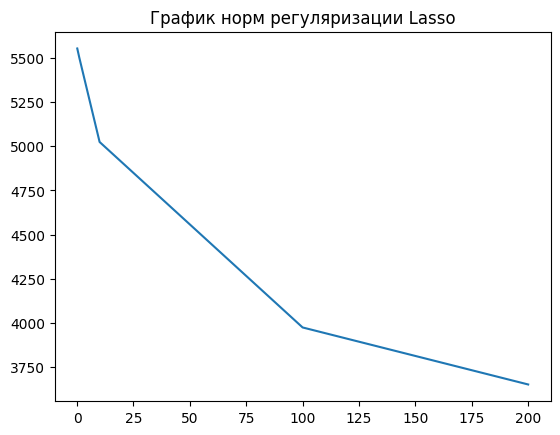

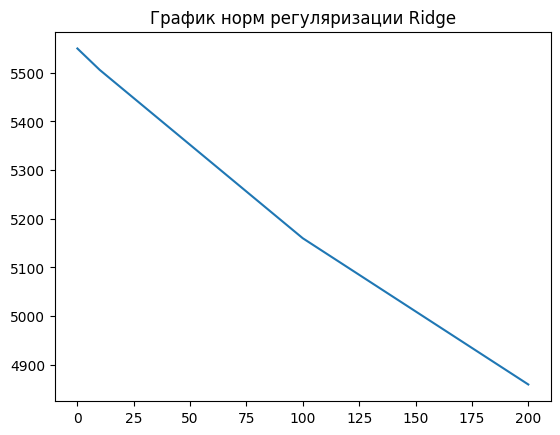

In [383]:
alpha_vals = [0.1, 1, 10, 100, 200]
lasso_norms = []
ridge_norms = []

for alpha in alpha_vals:
    ridge_model = Ridge(
        alpha=alpha
    )
    ridge_model.fit(
        X = X_train_scaled,
        y=y_train
    )
    lassso_model = Lasso(
        alpha=alpha
    )
    lassso_model.fit(
        X = X_train_scaled,
        y=y_train
    )
    lasso_norms.append(
        np.linalg.norm(lassso_model.coef_)
    )
    ridge_norms.append(
        np.linalg.norm(ridge_model.coef_)
    )

sns.lineplot(
    y = lasso_norms,
    x = alpha_vals
)
plt.title("График норм регуляризации Lasso")
plt.show()

sns.lineplot(
    y = ridge_norms,
    x = alpha_vals
)
plt.title("График норм регуляризации Ridge")
plt.show()

Lasso гораздо более резко уменьшает признаки. Из этого конечно напрямую не следует почему лассо зануляет признаки, но может показать что эта версия имееет право на жизнь

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [384]:
from sklearn.linear_model import LassoCV

In [385]:
lasso_cv_model = LassoCV(
    alphas=alpha_vals, 
    cv=10, 
    random_state=42
)

lasso_cv_model.fit(X_train_scaled, y_train)

df_alpha = pd.DataFrame(
    lasso_cv_model.mse_path_, 
    columns=[f'fold_{i+1}' for i in range(lasso_cv_model.mse_path_.shape[1])]
)
df_alpha['alpha'] = lasso_cv_model.alphas_
df_alpha['mean_mse'] = np.mean(lasso_cv_model.mse_path_, axis=1)
df_alpha['std_mse'] = np.std(lasso_cv_model.mse_path_, axis=1)

print(df_alpha)
print(f"Лучшая alpha: {lasso_cv_model.alpha_}")

         fold_1        fold_2        fold_3        fold_4        fold_5  \
0  2.016991e+06  2.037253e+06  1.874047e+06  2.117823e+06  1.967922e+06   
1  1.585118e+06  1.607535e+06  1.457886e+06  1.679231e+06  1.572688e+06   
2  1.328129e+06  1.361360e+06  1.196846e+06  1.425319e+06  1.405947e+06   
3  1.318533e+06  1.348506e+06  1.170407e+06  1.420259e+06  1.434987e+06   
4  1.318599e+06  1.348185e+06  1.168579e+06  1.420706e+06  1.439320e+06   

         fold_6        fold_7        fold_8        fold_9       fold_10  \
0  1.989657e+06  2.100788e+06  1.732283e+06  1.915618e+06  1.945757e+06   
1  1.556348e+06  1.659922e+06  1.336729e+06  1.502426e+06  1.509536e+06   
2  1.276580e+06  1.393685e+06  1.146628e+06  1.278731e+06  1.245944e+06   
3  1.249958e+06  1.378534e+06  1.139566e+06  1.267833e+06  1.225050e+06   
4  1.292032e+06  1.377916e+06  1.139980e+06  1.267600e+06  1.223893e+06   

   alpha      mean_mse        std_mse  
0  200.0  1.969814e+06  107396.453287  
1  100.0  1.546742

/Users/karlkorhonen/проекты/Data_analysis/IDA_FCS_course/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.313e+09, tolerance: 5.432e+07
  model = cd_fast.enet_coordinate_descent_gram(


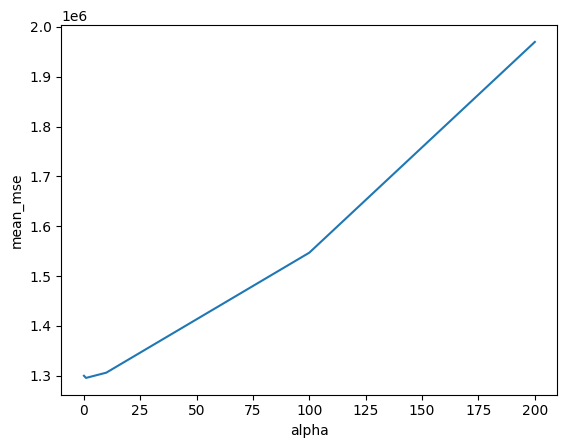

In [386]:
sns.lineplot(
    df_alpha,
    x = "alpha",
    y = "mean_mse"
)
plt.show()

**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [ ]:
lasso_model = Lasso(
    alpha=1
)

lassso_model.fit(
    X = X_train_scaled,
    y = y_train
)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lassso_model.coef_,
    'abs_coef': np.abs(lassso_model.coef_)
})

coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df)

          feature         coef     abs_coef
0           carat  3627.789879  3627.789879
21    clarity_SI2  -280.399886   280.399886
18     clarity_I1  -260.301869   260.301869
17        color_J  -125.313306   125.313306
20    clarity_SI1   -71.245679    71.245679
25   clarity_VVS2    12.929856    12.929856
16        color_I    -1.933777     1.933777
7        cut_Good    -0.000000     0.000000
24   clarity_VVS1     0.000000     0.000000
23    clarity_VS2     0.000000     0.000000
22    clarity_VS1     0.000000     0.000000
2           table    -0.000000     0.000000
3               x     0.000000     0.000000
19     clarity_IF     0.000000     0.000000
4               y     0.000000     0.000000
5               z     0.000000     0.000000
6        cut_Fair    -0.000000     0.000000
15        color_H    -0.000000     0.000000
14        color_G     0.000000     0.000000
1           depth    -0.000000     0.000000
12        color_E     0.000000     0.000000
11        color_D     0.000000  

In [388]:
print(
    coef_df[coef_df["abs_coef"]!=0]["feature"]
)

0            carat
21     clarity_SI2
18      clarity_I1
17         color_J
20     clarity_SI1
25    clarity_VVS2
16         color_I
Name: feature, dtype: str


Я думаю что сталис только эти признаки, потому что изначально было много скореллированных признаков, особенно с признаком карата. Чистота и цвет не связаны с массой, а также друг с другом, так что остались только важные призаки

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [ ]:
lasso_model = Lasso(
    alpha=1
)

lassso_model.fit(
    X = X_train_scaled,
    y = y_train
)

lasso_res = lassso_model.predict(
    X = X_test_scaled,
)

lasso_mse = mean_squared_error(
    y_test,
    lasso_res
)

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)


linreg_res = linreg.predict(
    X = X_test_scaled,
)

linreg_mse = mean_squared_error(
    y_test,
    linreg_res
)


print(f"Lasso MSE {lasso_mse}")
print()
print(f"Linreg MSE {linreg_mse}")

Lasso MSE 1244864.7437360557

Linreg MSE 1244765.435715868


Получилась очень маленькая разница. Мне кажется тут просто нужно использовать модель посложнее. Ну, в любом случае модель с регуляризацией оказалась лучше, по причине того, что она просто убрала ненужные признаки, а линейная регрессия в чистом виде могла немного поломаться на мультиколлинеарности признаков. Я бы юзал Lasso (на самом деле я бы просто скормил бы все в катбуст и был бы счастлив)